In [30]:
import sys

sys.path.insert(0, "..")

from pathlib import Path

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torchvision.io import ImageReadMode, read_image, write_png
from torchvision.transforms import Normalize
from torchvision.transforms.functional import InterpolationMode, resize
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks, draw_keypoints

from model.model import BackboneType, MultiNet

In [141]:
def rle_to_mask(rle: str, height: int, width: int):
    runs = torch.tensor([int(x) for x in rle.split()])
    starts = runs[::2]
    lengths = runs[1::2]
    mask = torch.zeros([height * width], dtype=torch.uint8)

    for start, lengths in zip(starts, lengths):
        start -= 1
        end = start + lengths
        mask[start:end] = 255
    return mask.reshape((height, width))


def generate_mask(rle_lung_left, rle_lung_right, rle_heart, height, width):
    mask_lung_left = rle_to_mask(rle_lung_left, height=height, width=width)
    mask_lung_right = rle_to_mask(rle_lung_right, height=height, width=width)
    mask_heart = rle_to_mask(rle_heart, height=height, width=width)
    mask_lung = mask_lung_left + mask_lung_right
    foreground = (mask_lung + mask_heart) - (mask_lung * mask_heart)
    background = torch.abs(255 - foreground)
    return torch.stack([background, mask_lung, mask_heart])


def get_ctr(output_tensor: torch.Tensor):
    heart_mask = (
        (output_tensor[0].sigmoid() > 0.5).permute([1, 2, 0])[..., 2].to(torch.uint8)
    )
    contours, _ = cv2.findContours(
        heart_mask.numpy(),
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    center_x_y, width_height, angle1 = cv2.minAreaRect(contours[0])
    w, h = width_height
    heart_width = w

    lung_mask = (
        (output_tensor[0].sigmoid() > 0.5).permute([1, 2, 0])[..., 1].to(torch.uint8)
    )
    contours, _ = cv2.findContours(
        lung_mask.numpy(),
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    center_x_y, width_height, angle2 = cv2.minAreaRect(contours[0])
    w, h = width_height
    lung_width = w

    return (heart_width + 0.0001) / (lung_width + 0.0001), contours[0]


def generate_visualization(original_image, output_tensor, dilation=False):
    heart_mask = (output_tensor[0].sigmoid().permute([1, 2, 0])[..., 2] > 0.5).to(
        torch.uint8
    )
    lung_mask = (output_tensor[0].sigmoid().permute([1, 2, 0])[..., 1] > 0.5).to(
        torch.uint8
    )

    heart_mask = heart_mask.numpy()
    x, y, w, h = cv2.boundingRect(heart_mask)
    heart_contour, _ = cv2.findContours(
        heart_mask,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_NONE,
    )

    lung_mask = lung_mask.numpy()
    x, y, w, h = cv2.boundingRect(lung_mask)
    lung_contour, _ = cv2.findContours(
        lung_mask,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_NONE,
    )

    # center_x_y, width_height, angle1 = cv2.minAreaRect(contours[0])
    # w, h = width_height
    # heart_width = w

    # image_bounding_box = draw_bounding_boxes(
    #     (original_image[0] * 255).to(torch.uint8),
    #     torch.tensor([[x, y, x + w, y + h]]),
    #     colors=(0, 0, 128),
    #     width=2,
    # )

    keypoints = torch.tensor(heart_contour)[..., 0, :]
    image_bounding_box = draw_keypoints(
        (original_image[0] * 255).to(torch.uint8),
        keypoints,
        radius=1,
        colors=(255, 0, 0),
    )
    for i in range(len(lung_contour)):
        keypoints = torch.tensor(lung_contour[i]).unsqueeze(0)[0, :]
        image_bounding_box = draw_keypoints(
            image_bounding_box,
            keypoints,
            radius=1,
            colors=(0, 255, 0),
        )

    # x, y, w, h = cv2.boundingRect(lung_mask.numpy())
    # image_bounding_box = draw_bounding_boxes(
    #     image_bounding_box,
    #     torch.tensor([[x, y, x + w, y + h]]),
    #     colors=(128, 0, 0),
    #     width=2,
    # )
    # image_bounding_box = draw_segmentation_masks(
    #     image_bounding_box,
    #     torch.Tensor(heart_mask).to(torch.bool),
    #     alpha=0.5,
    #     colors=(0, 0, 128),
    # )
    # image_bounding_box = draw_segmentation_masks(
    #     image_bounding_box,
    #     lung_mask.to(torch.bool),
    #     alpha=0.5,
    #     colors=(128, 64, 128),
    # )

    return image_bounding_box, lung_contour

In [4]:
if torch.backends.mps.is_available():
    print("Using MPS engine")
    device = "mps"
elif torch.cuda.is_available():
    print("Using CUDA engine")
    device = "cuda"
else:
    print("Using CPU engine")
    device = "cpu"

device = "cpu"
model = MultiNet(numberClass=3, backboneType=BackboneType.RESNET50)
preprocessor = Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]).to(device)

# Load weights into model
model.load_state_dict(
    torch.load(
        "../../data/model/cardiac_model_new_new_new_new_new_new.pt",
        map_location=device,
    )
)

Using MPS engine


<All keys matched successfully>

1.9392255415641348


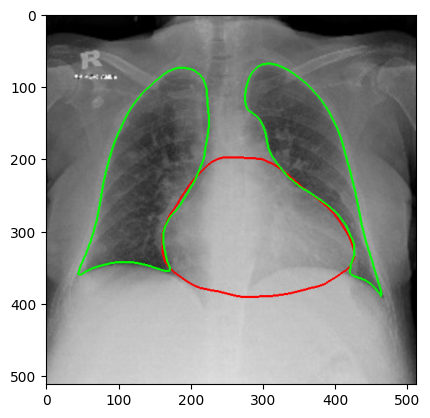

In [142]:
# Run single instance
CARDIOMEGALY_THRESHOLD = 0.5
image_path = "/Users/babi/Pictures/random.jpeg"

# Load image
image = read_image(image_path, ImageReadMode.RGB)
image = (image / 255).float().unsqueeze(0)

model.eval()
with torch.no_grad():
    original_image = resize(image, [512, 512], interpolation=InterpolationMode.BILINEAR)
    image = preprocessor(original_image)
    output_tensor = model(image)

pred_ctr, contours = get_ctr(output_tensor)
pred_is_cardiomegaly = pred_ctr > CARDIOMEGALY_THRESHOLD
print(pred_ctr)

visualization_tensor, contours = generate_visualization(
    original_image,
    output_tensor,
    dilation=False,
)

plt.imshow(visualization_tensor.permute([1, 2, 0]))

In [ ]:
# with h5py.File("/Volumes/storage/train_image.hdf5", "r") as file:
#     dataset_image = file["image"]
#     # dataset_label = file['label']
#     image = dataset_image[3]
#     # label = dataset_label[0]
#     plt.figure()
#     plt.imshow(np.transpose(image, [1, 2, 0]).astype(np.uint8))
#     plt.figure()
#     # plt.imshow(np.transpose(label, [1, 2, 0]).astype(np.uint8))

In [ ]:
# mask_pd = pd.read_csv(
#     "data/cardiac/chestxray.csv",
#     engine="pyarrow",
#     index_col=0,
# )
# mask_pd.head(5)

In [ ]:
# pd_data = pd.read_csv("data/cardiac/chestxray/Data_Entry_2017.csv", index_col=0)
# pd_data.head(5)

In [15]:
# Run evaluation on dataset images

if torch.backends.mps.is_available():
    print("Using MPS engine")
    device = "mps"
elif torch.cuda.is_available():
    print("Using CUDA engine")
    device = "cuda"
else:
    print("Using CPU engine")
    device = "cpu"

device = "cpu"
model = MultiNet(numberClass=3, backboneType=BackboneType.RESNET50)
preprocessor = Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]).to(device)

# Load weights into model
model.load_state_dict(
    torch.load(
        "../../data/model/cardiac_model_new_new_new_new_new_new.pt",
        map_location=device,
    )
)

CARDIOMEGALY_THRESHOLD = 0.5
bunch_of_images = [
    x for x in Path("data/cardiac/chestxray/").glob("images_*/images/*.png")
]

# image_path = ["/Volumes/storage/cardiomegaly-balance/00000016_000.png"]
image_path = ["/Volumes/storage/ProjekCOVID/covid19/CCW/CXR.jpg"]

true_positive, true_negative, false_positive, false_negative = 0, 0, 0, 0
for img_path in image_path:
    # Load image
    file_path = str(img_path)
    image = read_image(file_path, ImageReadMode.RGB)
    image = (image / 255).float().unsqueeze(0)

    # label_ctr_result = (
    #     pd_data.loc[str(img_path.name)]["Finding Labels"] == "Cardiomegaly"
    # )
    model.eval()
    with torch.no_grad():
        original_image = resize(
            image, [512, 512], interpolation=InterpolationMode.NEAREST
        )
        image = preprocessor(original_image)
        output_tensor = model(image)
        pred_ctr = get_ctr(output_tensor, dilation=False)
        pred_is_cardiomegaly = pred_ctr > CARDIOMEGALY_THRESHOLD
        print(pred_ctr)

        # row_of_interest = mask_pd.loc[str(img_path.name)]
        # mask_roi = generate_mask(
        #     rle_heart=row_of_interest["Heart"],
        #     rle_lung_left=row_of_interest["Left Lung"],
        #     rle_lung_right=row_of_interest["Right Lung"],
        #     height=row_of_interest["Height"],
        #     width=row_of_interest["Width"],
        # )
        # mask_roi = resize(mask_roi.float().unsqueeze(0), [512, 512])
        # label_ctr = get_ctr(mask_roi)
        # label_is_cardiomegaly = label_ctr > CARDIOMEGALY_THRESHOLD

        # if pred_is_cardiomegaly and label_is_cardiomegaly:
        #     true_positive += 1
        # elif pred_is_cardiomegaly and not label_is_cardiomegaly:
        #     false_positive += 1
        # elif not pred_is_cardiomegaly and label_is_cardiomegaly:
        #     false_negative += 1
        #     # visualization_tensor = generate_visualization(
        #     #     original_image,
        #     #     output_tensor,
        #     #     dilation=True,
        #     # )
        #     # write_png(visualization_tensor, f"visualization_{str(img_path.name)}")
        #     # print(label_ctr, pred_ctr)
        # else:
        #     true_negative += 1

        # if pred_is_cardiomegaly and label_ctr_result:
        #     true_positive += 1
        # elif pred_is_cardiomegaly and not label_ctr_result:
        #     false_positive += 1
        # elif not pred_is_cardiomegaly and label_ctr_result:
        #     false_negative += 1
        # else:
        #     true_negative += 1
        # print(pred_ctr, label_ctr, pred_is_cardiomegaly)

# precision = (true_positive + 0.00001) / (true_positive + false_positive + 0.00001)
# recall = (true_positive + 0.00001) / (true_positive + false_negative + 0.00001)
# accuracy = (true_positive + true_negative) / (
#     true_positive + true_negative + false_negative + false_positive
# )

# print("TruePositive TrueNegative FalsePositive FalseNegative")
# print(true_positive, true_negative, false_positive, false_negative)
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(
#     f"F1: {((2 * true_positive + 0.00001) / ((2 * true_positive) + false_positive + false_negative + 0.00001)):.4f}"
# )

Using MPS engine
0.5862212952826465


In [16]:
visualization_tensor = generate_visualization(
    original_image,
    output_tensor,
    dilation=True,
)
write_png(visualization_tensor, "test.png")